In [1]:
import pandas as pd
import numpy as np
import joblib

In [23]:
supplier_model = joblib.load(
    "supplier_risk_classification_model.joblib"
)

high_risk_model = joblib.load(
    "supplier_high_risk_model.joblib"
)

bottleneck_model = joblib.load(
    "bottleneck_risk_model.joblib"
)

print("All 3 models loaded successfully.")

All 3 models loaded successfully.


In [24]:
df_supplier = pd.read_csv(
    "Dy_Industrial_Dataset 2.csv"
)

df_production = pd.read_csv(
    "mfg005_synthetic_line_performance.csv"
)

df_analysis = pd.read_csv(
    "bottleneck_analysis_report.csv"
)

df_oee = pd.read_csv(
    "oee_summary_by_line.csv"
)

df_pareto = pd.read_csv(
    "downtime_pareto.csv"
)

print("All datasets loaded.")

All datasets loaded.


In [25]:
high_risk_preprocessor = (
    high_risk_model.named_steps["preprocessor"]
)

high_risk_features = (
    high_risk_preprocessor.feature_names_in_.tolist()
)

print("High-risk model expects:")
print(high_risk_features)

print("Number of features:",
      len(high_risk_features))

High-risk model expects:
['Raw_Material_Availability', 'Supplier_Cost_per_Unit', 'Lead_Time_Supplier', 'Reliability_Score', 'Defect_Rate', 'Energy_Cost_per_Unit', 'Distance_to_Market', 'Fuel_Cost_per_km', 'Delivery_Time', 'Vehicle_Utilization_Rate', 'Forecasted_Demand', 'Delivery_Satisfaction_Score', 'Delivery_Delay', 'Total_Cost', 'Delay_LeadTime_Ratio', 'Delivery_LeadTime_Ratio', 'Quality_Risk', 'Logistics_Burden', 'Supplier_Cost_Exposure']
Number of features: 19


In [26]:
bottleneck_preprocessor = (
    bottleneck_model.named_steps["preprocessor"]
)

bottleneck_features = (
    bottleneck_preprocessor.feature_names_in_.tolist()
)

print("Bottleneck model expects:")
print(bottleneck_features)

print("Number of features:",
      len(bottleneck_features))

Bottleneck model expects:
['number_of_stations', 'takt_time_seconds', 'designed_cycle_time_seconds', 'actual_cycle_time_avg_seconds', 'actual_cycle_time_std_seconds', 'actual_cycle_time_min_seconds', 'actual_cycle_time_max_seconds', 'cycle_time_percentile_p50', 'cycle_time_percentile_p95', 'cycle_time_cov', 'cycle_time_loss_seconds', 'planned_production_quantity', 'wip_queue_avg_units', 'wip_queue_max_units', 'planned_production_time_minutes', 'available_time_minutes', 'oee_availability', 'oee_performance', 'oee_quality', 'teep_pct', 'loading_pct', 'availability_loss_minutes', 'performance_loss_units', 'quality_loss_units', 'changeover_time_minutes', 'changeover_count', 'downtime_unplanned_minutes', 'downtime_planned_minutes', 'downtime_event_count', 'mtbf_minutes', 'mttr_minutes', 'largest_downtime_event_minutes', 'equipment_failure_flag', 'planned_maintenance_flag', 'equipment_age_years', 'equipment_condition_score', 'operator_headcount_planned', 'operator_headcount_actual', 'operato

In [27]:
df_supplier["Delay_LeadTime_Ratio"] = (
    df_supplier["Delivery_Delay"]
    / df_supplier["Lead_Time_Supplier"]
)

df_supplier["Delivery_LeadTime_Ratio"] = (
    df_supplier["Delivery_Time"]
    / df_supplier["Lead_Time_Supplier"]
)

df_supplier["Logistics_Burden"] = (
    df_supplier["Distance_to_Market"]
    * df_supplier["Fuel_Cost_per_km"]
)

df_supplier["Supplier_Cost_Exposure"] = (
    df_supplier["Supplier_Cost_per_Unit"]
    * df_supplier["Forecasted_Demand"]
)

In [10]:
df_supplier["Material_Demand_Coverage"] = (
    df_supplier["Raw_Material_Availability"]
    / df_supplier["Forecasted_Demand"]
)

df_supplier["Material_Shortage"] = (
    df_supplier["Forecasted_Demand"]
    - df_supplier["Raw_Material_Availability"]
)

df_supplier["Delay_LeadTime_Ratio"] = (
    df_supplier["Delivery_Delay"]
    / df_supplier["Lead_Time_Supplier"]
)

df_supplier["Delivery_LeadTime_Ratio"] = (
    df_supplier["Delivery_Time"]
    / df_supplier["Lead_Time_Supplier"]
)

df_supplier["Logistics_Burden"] = (
    df_supplier["Distance_to_Market"]
    * df_supplier["Fuel_Cost_per_km"]
)

df_supplier["Supplier_Cost_Exposure"] = (
    df_supplier["Supplier_Cost_per_Unit"]
    * df_supplier["Forecasted_Demand"]
)

In [28]:
missing = [
    col for col in high_risk_features
    if col not in df_supplier.columns
]

print("Missing features:", missing)

Missing features: ['Quality_Risk']


In [13]:
missing_features = [
    feature
    for feature in supplier_features
    if feature not in df_supplier.columns
]

print("Missing features:")
print(missing_features)

Missing features:
['Quality_Risk']


In [29]:
df_supplier["Quality_Risk"] = (
    df_supplier["Defect_Rate"] / 3.0
).clip(0, 1)

In [30]:
print(df_supplier["Quality_Risk"].describe())

count    2342.000000
mean        0.583524
std         0.242148
min         0.166667
25%         0.373333
50%         0.583333
75%         0.799167
max         1.000000
Name: Quality_Risk, dtype: float64


In [31]:
missing = [
    col for col in high_risk_features
    if col not in df_supplier.columns
]

print("Missing:", missing)

Missing: []


In [32]:
X_supplier = df_supplier[high_risk_features].copy()

print("Shape:", X_supplier.shape)
print("Missing values:", X_supplier.isnull().sum().sum())
print("Infinite values:",
      np.isinf(X_supplier.select_dtypes(include=np.number)).sum().sum())

Shape: (2342, 19)
Missing values: 0
Infinite values: 0


In [19]:
X_supplier_input = df_supplier[supplier_features].copy()

print("Input shape:", X_supplier_input.shape)

print("\nInput dtypes:")
print(X_supplier_input.dtypes)

Input shape: (2342, 21)

Input dtypes:
Raw_Material_Availability        int64
Supplier_Cost_per_Unit         float64
Lead_Time_Supplier               int64
Reliability_Score              float64
Defect_Rate                    float64
Energy_Cost_per_Unit           float64
Distance_to_Market               int64
Fuel_Cost_per_km               float64
Delivery_Time                    int64
Vehicle_Utilization_Rate       float64
Forecasted_Demand                int64
Delivery_Satisfaction_Score    float64
Delivery_Delay                   int64
Total_Cost                       int64
Material_Demand_Coverage       float64
Material_Shortage                int64
Delay_LeadTime_Ratio           float64
Delivery_LeadTime_Ratio        float64
Quality_Risk                   float64
Logistics_Burden               float64
Supplier_Cost_Exposure         float64
dtype: object


In [33]:
X_supplier = df_supplier[high_risk_features].copy()

print("Shape:", X_supplier.shape)
print("Missing values:", X_supplier.isnull().sum().sum())
print("Infinite values:",
      np.isinf(X_supplier.select_dtypes(include=np.number)).sum().sum())

Shape: (2342, 19)
Missing values: 0
Infinite values: 0


In [36]:
supplier_high_probability = (
    high_risk_model.predict_proba(X_supplier)[:, 1]
)

df_supplier["Supplier_High_Risk_Probability"] = (
    supplier_high_probability
)

In [39]:
X_supplier = df_supplier[high_risk_features].copy()

print("Shape:", X_supplier.shape)
print("Missing values:", X_supplier.isnull().sum().sum())

Shape: (2342, 19)
Missing values: 0


In [40]:
supplier_high_probability = (
    high_risk_model.predict_proba(X_supplier)[:, 1]
)

df_supplier["Supplier_High_Risk_Probability"] = (
    supplier_high_probability
)

print(
    df_supplier[
        [
            "Supplier_ID",
            "Supplier_High_Risk_Probability"
        ]
    ].head(10)
)

  Supplier_ID  Supplier_High_Risk_Probability
0        S039                        0.000001
1        S029                        0.999843
2        S015                        0.001053
3        S043                        0.000012
4        S008                        0.000066
5        S021                        0.003608
6        S039                        0.005568
7        S019                        0.000004
8        S023                        0.000229
9        S011                        0.000041


In [41]:
def risk_category(probability):
    if probability >= 0.70:
        return "High"
    elif probability >= 0.40:
        return "Medium"
    else:
        return "Low"

In [42]:
df_supplier["Supplier_Risk_Level"] = (
    df_supplier["Supplier_High_Risk_Probability"]
    .apply(risk_category)
)

In [43]:
print(
    df_supplier[
        [
            "Supplier_ID",
            "Supplier_High_Risk_Probability",
            "Supplier_Risk_Level"
        ]
    ].head(15)
)

   Supplier_ID  Supplier_High_Risk_Probability Supplier_Risk_Level
0         S039                        0.000001                 Low
1         S029                        0.999843                High
2         S015                        0.001053                 Low
3         S043                        0.000012                 Low
4         S008                        0.000066                 Low
5         S021                        0.003608                 Low
6         S039                        0.005568                 Low
7         S019                        0.000004                 Low
8         S023                        0.000229                 Low
9         S011                        0.000041                 Low
10        S011                        0.000003                 Low
11        S024                        0.000018                 Low
12        S036                        0.652747              Medium
13        S040                        0.000193                

In [44]:
print(
    df_supplier["Supplier_Risk_Level"].value_counts()
)

Supplier_Risk_Level
Low       2135
High       184
Medium      23
Name: count, dtype: int64


In [45]:
X_production = df_production[bottleneck_features].copy()

print("Shape:", X_production.shape)
print("Missing:", X_production.isnull().sum().sum())

Shape: (3000, 49)
Missing: 0


In [46]:
bottleneck_probability = (
    bottleneck_model.predict_proba(X_production)[:, 1]
)

df_production["Bottleneck_Risk_Probability"] = (
    bottleneck_probability
)

In [47]:
df_production["Bottleneck_Risk_Level"] = (
    df_production["Bottleneck_Risk_Probability"]
    .apply(risk_category)
)

In [48]:
print(
    df_production[
        [
            "line_id",
            "product_id",
            "Bottleneck_Risk_Probability",
            "Bottleneck_Risk_Level"
        ]
    ].head(15)
)

                line_id          product_id  Bottleneck_Risk_Probability  \
0   MFG-LINE-PLT-004-06  PRD-2021-SKU-05702                     0.715715   
1   MFG-LINE-PLT-005-05  PRD-2020-SKU-05736                     0.033418   
2   MFG-LINE-PLT-005-01  PRD-2022-SKU-04660                     0.430607   
3   MFG-LINE-PLT-007-02  PRD-2023-SKU-01042                     0.591681   
4   MFG-LINE-PLT-001-02  PRD-2024-SKU-02680                     0.789910   
5   MFG-LINE-PLT-006-02  PRD-2020-SKU-03525                     0.954936   
6   MFG-LINE-PLT-005-05  PRD-2024-SKU-02707                     0.009306   
7   MFG-LINE-PLT-005-04  PRD-2024-SKU-07919                     0.686872   
8   MFG-LINE-PLT-002-04  PRD-2020-SKU-07478                     0.963650   
9   MFG-LINE-PLT-003-03  PRD-2020-SKU-07716                     0.052889   
10  MFG-LINE-PLT-010-04  PRD-2023-SKU-03844                     0.812911   
11  MFG-LINE-PLT-010-04  PRD-2024-SKU-09427                     0.791027   
12  MFG-LINE

In [49]:
print(
    df_production["Bottleneck_Risk_Level"]
    .value_counts()
)

Bottleneck_Risk_Level
Low       1428
High       879
Medium     693
Name: count, dtype: int64


In [50]:
print(df_supplier[
    [
        "Supplier_ID",
        "Manufacturer_ID",
        "Logistics_ID",
        "Forecasted_Demand",
        "Raw_Material_Availability",
        "Supplier_High_Risk_Probability"
    ]
].head(20))

   Supplier_ID Manufacturer_ID Logistics_ID  Forecasted_Demand  \
0         S039            M002         L012                856   
1         S029            M022         L016               1005   
2         S015            M013         L001                947   
3         S043            M012         L008               1078   
4         S008            M015         L001               1089   
5         S021            M027         L020                820   
6         S039            M009         L019                936   
7         S019            M002         L004                809   
8         S023            M017         L014                844   
9         S011            M027         L014               1048   
10        S011            M029         L009                829   
11        S024            M005         L009               1024   
12        S036            M011         L017                976   
13        S040            M022         L015                895   
14        

In [51]:
print(df_production[
    [
        "product_id",
        "product_family",
        "production_order_id",
        "line_id",
        "plant_id"
    ]
].head(20))

            product_id        product_family production_order_id  \
0   PRD-2021-SKU-05702  industrial_machinery       WO-2021-98019   
1   PRD-2020-SKU-05736       automotive_body       WO-2020-36066   
2   PRD-2022-SKU-04660       automotive_body       WO-2022-67019   
3   PRD-2023-SKU-01042  industrial_machinery       WO-2023-12387   
4   PRD-2024-SKU-02680        pharmaceutical       WO-2024-99757   
5   PRD-2020-SKU-03525         food_beverage       WO-2020-85336   
6   PRD-2024-SKU-02707       automotive_body       WO-2024-01817   
7   PRD-2024-SKU-07919       automotive_body       WO-2024-13111   
8   PRD-2020-SKU-07478       electronics_pcb       WO-2020-24841   
9   PRD-2020-SKU-07716       electronics_pcb       WO-2020-74961   
10  PRD-2023-SKU-03844  industrial_machinery       WO-2023-84331   
11  PRD-2024-SKU-09427  industrial_machinery       WO-2024-41666   
12  PRD-2023-SKU-02419  industrial_machinery       WO-2023-38537   
13  PRD-2020-SKU-05777       electronics_pcb    

In [52]:
supplier_summary = (
    df_supplier
    .groupby("Supplier_ID")
    .agg(
        Supplier_High_Risk_Probability=(
            "Supplier_High_Risk_Probability",
            "mean"
        ),
        Max_Supplier_Risk=(
            "Supplier_High_Risk_Probability",
            "max"
        ),
        Avg_Material_Availability=(
            "Raw_Material_Availability",
            "mean"
        ),
        Avg_Forecasted_Demand=(
            "Forecasted_Demand",
            "mean"
        ),
        Avg_Reliability=(
            "Reliability_Score",
            "mean"
        ),
        Avg_Delivery_Delay=(
            "Delivery_Delay",
            "mean"
        )
    )
    .reset_index()
)

In [53]:
line_risk_summary = (
    df_production
    .groupby("line_id")
    .agg(
        Bottleneck_Risk_Probability=(
            "Bottleneck_Risk_Probability",
            "mean"
        ),
        Max_Bottleneck_Risk=(
            "Bottleneck_Risk_Probability",
            "max"
        ),
        Avg_Production_OEE=(
            "oee_overall",
            "mean"
        ),
        Avg_Machine_Utilization=(
            "operator_utilisation_pct",
            "mean"
        ),
        Total_Unplanned_Downtime=(
            "downtime_unplanned_minutes",
            "sum"
        )
    )
    .reset_index()
)

In [54]:
print(line_risk_summary.shape)

print(
    line_risk_summary.sort_values(
        "Bottleneck_Risk_Probability",
        ascending=False
    ).head(15)
)

(36, 6)
                line_id  Bottleneck_Risk_Probability  Max_Bottleneck_Risk  \
25  MFG-LINE-PLT-006-02                     0.973807             0.999374   
24  MFG-LINE-PLT-006-01                     0.930235             0.992804   
5   MFG-LINE-PLT-002-04                     0.929085             0.995639   
34  MFG-LINE-PLT-010-03                     0.894375             0.978390   
30  MFG-LINE-PLT-009-01                     0.890618             0.968551   
1   MFG-LINE-PLT-001-02                     0.758689             0.915751   
35  MFG-LINE-PLT-010-04                     0.749948             0.892273   
33  MFG-LINE-PLT-010-02                     0.737798             0.923694   
10  MFG-LINE-PLT-003-05                     0.693924             0.882690   
12  MFG-LINE-PLT-004-02                     0.653782             0.867108   
16  MFG-LINE-PLT-004-06                     0.639144             0.811839   
14  MFG-LINE-PLT-004-04                     0.594276             0.8

In [55]:
print(
    df_supplier[
        [
            "Supplier_ID",
            "Manufacturer_ID"
        ]
    ].drop_duplicates().head(30)
)

   Supplier_ID Manufacturer_ID
0         S039            M002
1         S029            M022
2         S015            M013
3         S043            M012
4         S008            M015
5         S021            M027
6         S039            M009
7         S019            M002
8         S023            M017
9         S011            M027
10        S011            M029
11        S024            M005
12        S036            M011
13        S040            M022
14        S024            M019
15        S003            M024
16        S022            M007
17        S002            M002
18        S024            M016
19        S044            M012
20        S030            M023
21        S038            M015
22        S002            M001
23        S021            M025
24        S033            M013
25        S012            M023
26        S022            M006
27        S044            M013
28        S025            M018
29        S049            M003


In [56]:
print(
    df_production[
        [
            "plant_id",
            "line_id"
        ]
    ].drop_duplicates().head(30)
)

   plant_id              line_id
0   PLT-004  MFG-LINE-PLT-004-06
1   PLT-005  MFG-LINE-PLT-005-05
2   PLT-005  MFG-LINE-PLT-005-01
3   PLT-007  MFG-LINE-PLT-007-02
4   PLT-001  MFG-LINE-PLT-001-02
5   PLT-006  MFG-LINE-PLT-006-02
7   PLT-005  MFG-LINE-PLT-005-04
8   PLT-002  MFG-LINE-PLT-002-04
9   PLT-003  MFG-LINE-PLT-003-03
10  PLT-010  MFG-LINE-PLT-010-04
12  PLT-004  MFG-LINE-PLT-004-01
13  PLT-003  MFG-LINE-PLT-003-04
14  PLT-010  MFG-LINE-PLT-010-03
15  PLT-004  MFG-LINE-PLT-004-07
16  PLT-005  MFG-LINE-PLT-005-03
17  PLT-004  MFG-LINE-PLT-004-02
18  PLT-002  MFG-LINE-PLT-002-03
19  PLT-004  MFG-LINE-PLT-004-04
20  PLT-004  MFG-LINE-PLT-004-03
21  PLT-007  MFG-LINE-PLT-007-01
24  PLT-009  MFG-LINE-PLT-009-01
25  PLT-004  MFG-LINE-PLT-004-05
26  PLT-003  MFG-LINE-PLT-003-05
29  PLT-010  MFG-LINE-PLT-010-02
41  PLT-009  MFG-LINE-PLT-009-02
51  PLT-010  MFG-LINE-PLT-010-01
52  PLT-008  MFG-LINE-PLT-008-02
54  PLT-003  MFG-LINE-PLT-003-01
62  PLT-005  MFG-LINE-PLT-005-06
74  PLT-00

In [57]:
df_production["Plant_ID"] = df_production["plant_id"]

In [58]:
plant_risk_summary = (
    df_production
    .groupby("Plant_ID")
    .agg(
        Avg_Bottleneck_Risk=(
            "Bottleneck_Risk_Probability",
            "mean"
        ),
        Max_Bottleneck_Risk=(
            "Bottleneck_Risk_Probability",
            "max"
        ),
        Avg_OEE=(
            "oee_overall",
            "mean"
        ),
        Total_Unplanned_Downtime=(
            "downtime_unplanned_minutes",
            "sum"
        ),
        Production_Records=(
            "line_id",
            "count"
        )
    )
    .reset_index()
)

In [59]:
print(
    plant_risk_summary.sort_values(
        "Avg_Bottleneck_Risk",
        ascending=False
    )
)

  Plant_ID  Avg_Bottleneck_Risk  Max_Bottleneck_Risk   Avg_OEE  \
5  PLT-006             0.952300             0.999374  0.646451   
9  PLT-010             0.722472             0.978390  0.648883   
7  PLT-008             0.520503             0.789688  0.690253   
8  PLT-009             0.456225             0.968551  0.647390   
3  PLT-004             0.405911             0.892271  0.645064   
1  PLT-002             0.395145             0.995639  0.670003   
0  PLT-001             0.364676             0.915751  0.673594   
2  PLT-003             0.352926             0.882690  0.643296   
4  PLT-005             0.350757             0.860990  0.642945   
6  PLT-007             0.282592             0.873032  0.662899   

   Total_Unplanned_Downtime  Production_Records  
5              12183.898535                 156  
9              21181.739492                 355  
7               7426.007324                 165  
8              10121.600000                 151  
3              41491.15

In [60]:
supplier_summary["Material_Coverage"] = (
    supplier_summary["Avg_Material_Availability"]
    / supplier_summary["Avg_Forecasted_Demand"]
)

supplier_summary["Material_Risk_Score"] = (
    1 - supplier_summary["Material_Coverage"]
).clip(0, 1)

In [61]:
supplier_summary["Supplier_Risk_Score"] = (
    supplier_summary[
        "Supplier_High_Risk_Probability"
    ]
)

In [62]:
df_production["Potential_Downtime_Exposure"] = (
    df_production["Bottleneck_Risk_Probability"]
    *
    df_production["total_downtime_cost_usd"]
)

In [63]:
plant_risk_summary = plant_risk_summary.rename(
    columns={
        "Avg_Machine_Utilization":
        "Avg_Operator_Utilization"
    }
)

In [64]:
plant_financial = (
    df_production
    .groupby("plant_id")
    .agg(
        Total_Downtime_Cost=(
            "total_downtime_cost_usd",
            "sum"
        ),
        Total_Quality_Cost=(
            "cost_of_poor_quality_usd",
            "sum"
        ),
        Avg_Production_Cost=(
            "production_cost_per_unit_usd",
            "mean"
        ),
        Total_Unplanned_Downtime=(
            "downtime_unplanned_minutes",
            "sum"
        )
    )
    .reset_index()
)

In [66]:
plant_risk_summary = plant_risk_summary.rename(
    columns={"Plant_ID": "plant_id"}
)

In [67]:
print(plant_risk_summary.columns.tolist())
print(plant_financial.columns.tolist())

['plant_id', 'Avg_Bottleneck_Risk', 'Max_Bottleneck_Risk', 'Avg_OEE', 'Total_Unplanned_Downtime', 'Production_Records']
['plant_id', 'Total_Downtime_Cost', 'Total_Quality_Cost', 'Avg_Production_Cost', 'Total_Unplanned_Downtime']


In [68]:
plant_risk_final = plant_risk_summary.merge(
    plant_financial,
    on="plant_id",
    how="left"
)

In [70]:
plant_risk_final["Expected_Downtime_Exposure"] = (
    plant_risk_final["Avg_Bottleneck_Risk"]
    *
    plant_risk_final["Total_Downtime_Cost"]
)

In [71]:
print(
    plant_risk_final[
        [
            "plant_id",
            "Avg_Bottleneck_Risk",
            "Avg_OEE",
            "Total_Downtime_Cost",
            "Expected_Downtime_Exposure"
        ]
    ].sort_values(
        "Expected_Downtime_Exposure",
        ascending=False
    )
)

  plant_id  Avg_Bottleneck_Risk   Avg_OEE  Total_Downtime_Cost  \
4  PLT-005             0.350757  0.642945           7000527.93   
3  PLT-004             0.405911  0.645064           4149115.15   
2  PLT-003             0.352926  0.643296           4378022.86   
9  PLT-010             0.722472  0.648883           2118173.95   
1  PLT-002             0.395145  0.670003           2644803.37   
7  PLT-008             0.520503  0.690253           1856501.84   
5  PLT-006             0.952300  0.646451            974711.89   
8  PLT-009             0.456225  0.647390           2024320.00   
0  PLT-001             0.364676  0.673594           2277685.59   
6  PLT-007             0.282592  0.662899            916250.00   

   Expected_Downtime_Exposure  
4                2.455481e+06  
3                1.684171e+06  
2                1.545116e+06  
9                1.530322e+06  
1                1.045080e+06  
7                9.663156e+05  
5                9.282185e+05  
8                

In [74]:
print(plant_risk_final.columns.tolist())

['plant_id', 'Avg_Bottleneck_Risk', 'Max_Bottleneck_Risk', 'Avg_OEE', 'Total_Unplanned_Downtime_x', 'Production_Records', 'Total_Downtime_Cost', 'Total_Quality_Cost', 'Avg_Production_Cost', 'Total_Unplanned_Downtime_y', 'Expected_Downtime_Exposure', 'Disruption_Level']


In [76]:
final_plant_risk = (
    plant_risk_final[
        [
            "plant_id",
            "Avg_Bottleneck_Risk",
            "Avg_OEE",
            "Total_Unplanned_Downtime_y",
            "Total_Downtime_Cost",
            "Expected_Downtime_Exposure",
            "Disruption_Level"
        ]
    ]
    .rename(
        columns={
            "Total_Unplanned_Downtime_y":
            "Total_Unplanned_Downtime"
        }
    )
    .sort_values(
        "Expected_Downtime_Exposure",
        ascending=False
    )
)

print(final_plant_risk.to_string(index=False))

plant_id  Avg_Bottleneck_Risk  Avg_OEE  Total_Unplanned_Downtime  Total_Downtime_Cost  Expected_Downtime_Exposure Disruption_Level
 PLT-005             0.350757 0.642945              35002.639650           7000527.93                2.455481e+06           Medium
 PLT-004             0.405911 0.645064              41491.151547           4149115.15                1.684171e+06             High
 PLT-003             0.352926 0.643296              29186.819007           4378022.86                1.545116e+06           Medium
 PLT-010             0.722472 0.648883              21181.739492           2118173.95                1.530322e+06         Critical
 PLT-002             0.395145 0.670003              17632.022537           2644803.37                1.045080e+06           Medium
 PLT-008             0.520503 0.690253               7426.007324           1856501.84                9.663156e+05             High
 PLT-006             0.952300 0.646451              12183.898535            974711.

In [77]:
plant_risk_final = plant_risk_final.drop(
    columns=[
        "Total_Unplanned_Downtime_x",
        "Total_Unplanned_Downtime_y"
    ]
)

plant_risk_final = plant_risk_final.rename(
    columns={
        # only if needed later
    }
)

In [78]:
from sklearn.preprocessing import MinMaxScaler

final_plant_risk["OEE_Risk"] = (
    1 - final_plant_risk["Avg_OEE"]
)

scaler = MinMaxScaler()

final_plant_risk["Financial_Risk"] = (
    scaler.fit_transform(
        final_plant_risk[
            ["Expected_Downtime_Exposure"]
        ]
    ).ravel()
)

final_plant_risk["Priority_Score"] = (
    0.50 * final_plant_risk["Avg_Bottleneck_Risk"]
    + 0.30 * final_plant_risk["Financial_Risk"]
    + 0.20 * final_plant_risk["OEE_Risk"]
)

In [79]:
final_plant_risk = final_plant_risk.sort_values(
    "Priority_Score",
    ascending=False
)

print(
    final_plant_risk[
        [
            "plant_id",
            "Avg_Bottleneck_Risk",
            "Avg_OEE",
            "Total_Downtime_Cost",
            "Expected_Downtime_Exposure",
            "Priority_Score",
            "Disruption_Level"
        ]
    ].to_string(index=False)
)

plant_id  Avg_Bottleneck_Risk  Avg_OEE  Total_Downtime_Cost  Expected_Downtime_Exposure  Priority_Score Disruption_Level
 PLT-006             0.952300 0.646451            974711.89                9.282185e+05        0.638270         Critical
 PLT-010             0.722472 0.648883           2118173.95                1.530322e+06        0.605104         Critical
 PLT-005             0.350757 0.642945           7000527.93                2.455481e+06        0.546789           Medium
 PLT-004             0.405911 0.645064           4149115.15                1.684171e+06        0.468599             High
 PLT-003             0.352926 0.643296           4378022.86                1.545116e+06        0.423468           Medium
 PLT-008             0.520503 0.690253           1856501.84                9.663156e+05        0.418815             High
 PLT-009             0.456225 0.647390           2024320.00                9.235450e+05        0.389406             High
 PLT-002             0.395145 0.

In [80]:
def generate_recommendation(row):

    risk = row["Avg_Bottleneck_Risk"]
    oee = row["Avg_OEE"]
    exposure = row["Expected_Downtime_Exposure"]

    recommendations = []

    # Bottleneck action
    if risk >= 0.70:
        recommendations.append(
            "Immediate bottleneck investigation"
        )
        recommendations.append(
            "Prioritize maintenance resources"
        )

    elif risk >= 0.40:
        recommendations.append(
            "Monitor bottleneck station closely"
        )
        recommendations.append(
            "Schedule preventive maintenance"
        )

    else:
        recommendations.append(
            "Continue routine bottleneck monitoring"
        )

    # OEE action
    if oee < 0.65:
        recommendations.append(
            "Investigate low OEE"
        )

    elif oee < 0.70:
        recommendations.append(
            "Improve OEE performance"
        )

    # Financial action
    if exposure >= 2_000_000:
        recommendations.append(
            "High financial exposure — prioritize production continuity"
        )

    elif exposure >= 1_000_000:
        recommendations.append(
            "Review production scheduling and downtime reduction"
        )

    else:
        recommendations.append(
            "Maintain current production plan"
        )

    return " | ".join(recommendations)

In [81]:
final_plant_risk["Recommendation"] = (
    final_plant_risk.apply(
        generate_recommendation,
        axis=1
    )
)

In [82]:
recommendation_table = final_plant_risk[
    [
        "plant_id",
        "Avg_Bottleneck_Risk",
        "Avg_OEE",
        "Expected_Downtime_Exposure",
        "Priority_Score",
        "Disruption_Level",
        "Recommendation"
    ]
].sort_values(
    "Priority_Score",
    ascending=False
)

print(
    recommendation_table.to_string(index=False)
)

plant_id  Avg_Bottleneck_Risk  Avg_OEE  Expected_Downtime_Exposure  Priority_Score Disruption_Level                                                                                                                                    Recommendation
 PLT-006             0.952300 0.646451                9.282185e+05        0.638270         Critical                    Immediate bottleneck investigation | Prioritize maintenance resources | Investigate low OEE | Maintain current production plan
 PLT-010             0.722472 0.648883                1.530322e+06        0.605104         Critical Immediate bottleneck investigation | Prioritize maintenance resources | Investigate low OEE | Review production scheduling and downtime reduction
 PLT-005             0.350757 0.642945                2.455481e+06        0.546789           Medium                         Continue routine bottleneck monitoring | Investigate low OEE | High financial exposure — prioritize production continuity
 PLT-004        

In [83]:
def generate_recommendation(row):

    risk = row["Avg_Bottleneck_Risk"]
    oee = row["Avg_OEE"]
    exposure = row["Expected_Downtime_Exposure"]

    recommendations = []

    # Bottleneck action
    if risk >= 0.70:
        recommendations.append(
            "Immediate bottleneck investigation"
        )
        recommendations.append(
            "Prioritize maintenance resources"
        )
        recommendations.append(
            "Review production scheduling"
        )

    elif risk >= 0.40:
        recommendations.append(
            "Monitor bottleneck station closely"
        )
        recommendations.append(
            "Schedule preventive maintenance"
        )

    else:
        recommendations.append(
            "Continue routine bottleneck monitoring"
        )

    # OEE action
    if oee < 0.65:
        recommendations.append(
            "Investigate low OEE"
        )

    elif oee < 0.70:
        recommendations.append(
            "Improve OEE performance"
        )

    # Financial action
    if exposure >= 2_000_000:
        recommendations.append(
            "High financial exposure — prioritize production continuity"
        )

    elif exposure >= 1_000_000:
        recommendations.append(
            "Review downtime reduction and production scheduling"
        )

    else:
        recommendations.append(
            "Maintain current production plan"
        )

    return " | ".join(recommendations)

In [84]:
final_plant_risk["Recommendation"] = (
    final_plant_risk.apply(
        generate_recommendation,
        axis=1
    )
)

In [85]:
print(
    final_plant_risk[
        [
            "plant_id",
            "Avg_Bottleneck_Risk",
            "Avg_OEE",
            "Expected_Downtime_Exposure",
            "Priority_Score",
            "Disruption_Level",
            "Recommendation"
        ]
    ].sort_values(
        "Priority_Score",
        ascending=False
    ).to_string(index=False)
)

plant_id  Avg_Bottleneck_Risk  Avg_OEE  Expected_Downtime_Exposure  Priority_Score Disruption_Level                                                                                                                                                                   Recommendation
 PLT-006             0.952300 0.646451                9.282185e+05        0.638270         Critical                    Immediate bottleneck investigation | Prioritize maintenance resources | Review production scheduling | Investigate low OEE | Maintain current production plan
 PLT-010             0.722472 0.648883                1.530322e+06        0.605104         Critical Immediate bottleneck investigation | Prioritize maintenance resources | Review production scheduling | Investigate low OEE | Review downtime reduction and production scheduling
 PLT-005             0.350757 0.642945                2.455481e+06        0.546789           Medium                                                        Continue routi

In [86]:
print(
    final_plant_risk["Disruption_Level"].value_counts()
)

Disruption_Level
Medium      5
High        3
Critical    2
Name: count, dtype: int64


In [87]:
final_plant_risk.to_csv(
    "final_plant_risk.csv",
    index=False
)

print("Saved: final_plant_risk.csv")

Saved: final_plant_risk.csv


In [88]:
supplier_output = df_supplier[
    [
        "Supplier_ID",
        "Manufacturer_ID",
        "Forecasted_Demand",
        "Raw_Material_Availability",
        "Reliability_Score",
        "Delivery_Delay",
        "Supplier_High_Risk_Probability",
        "Supplier_Risk_Level"
    ]
].copy()

supplier_output.to_csv(
    "supplier_predictions.csv",
    index=False
)

print("Saved: supplier_predictions.csv")

Saved: supplier_predictions.csv


In [89]:
bottleneck_output = df_production[
    [
        "line_id",
        "plant_id",
        "product_id",
        "production_order_id",
        "Bottleneck_Risk_Probability",
        "Bottleneck_Risk_Level",
        "oee_overall",
        "downtime_unplanned_minutes",
        "bottleneck_station_id"
    ]
].copy()

bottleneck_output.to_csv(
    "production_bottleneck_predictions.csv",
    index=False
)

print("Saved: production_bottleneck_predictions.csv")

Saved: production_bottleneck_predictions.csv


In [90]:
plant_risk_summary.to_csv(
    "plant_bottleneck_summary.csv",
    index=False
)

print("Saved: plant_bottleneck_summary.csv")

Saved: plant_bottleneck_summary.csv


In [91]:
import os

files = [
    "supplier_predictions.csv",
    "production_bottleneck_predictions.csv",
    "plant_bottleneck_summary.csv",
    "final_plant_risk.csv"
]

for file in files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file)

✓ supplier_predictions.csv
✓ production_bottleneck_predictions.csv
✓ plant_bottleneck_summary.csv
✓ final_plant_risk.csv


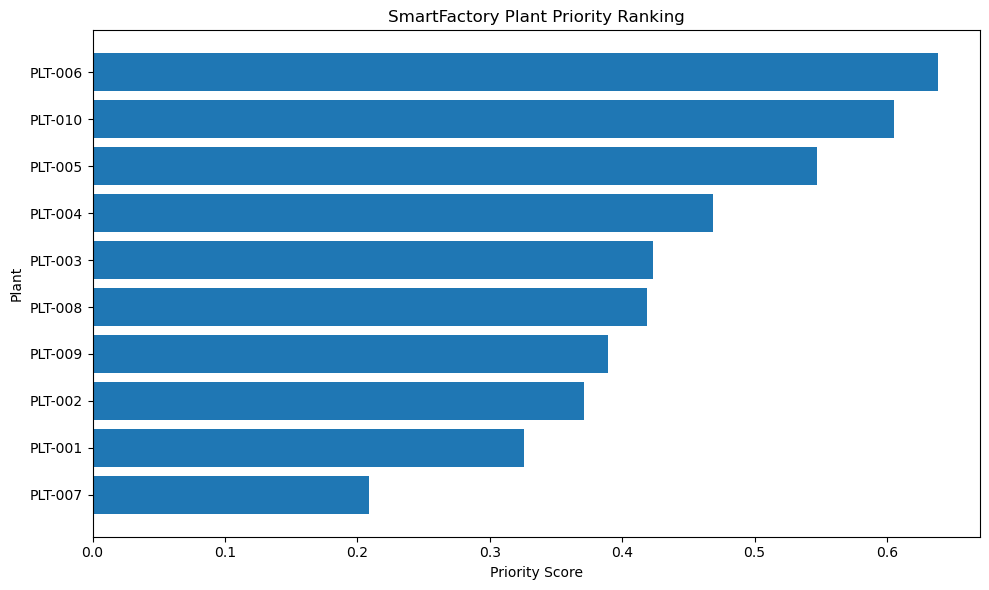

In [92]:
import matplotlib.pyplot as plt

plot_data = final_plant_risk.sort_values(
    "Priority_Score",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["plant_id"],
    plot_data["Priority_Score"]
)

plt.xlabel("Priority Score")
plt.ylabel("Plant")
plt.title("SmartFactory Plant Priority Ranking")

plt.tight_layout()
plt.show()

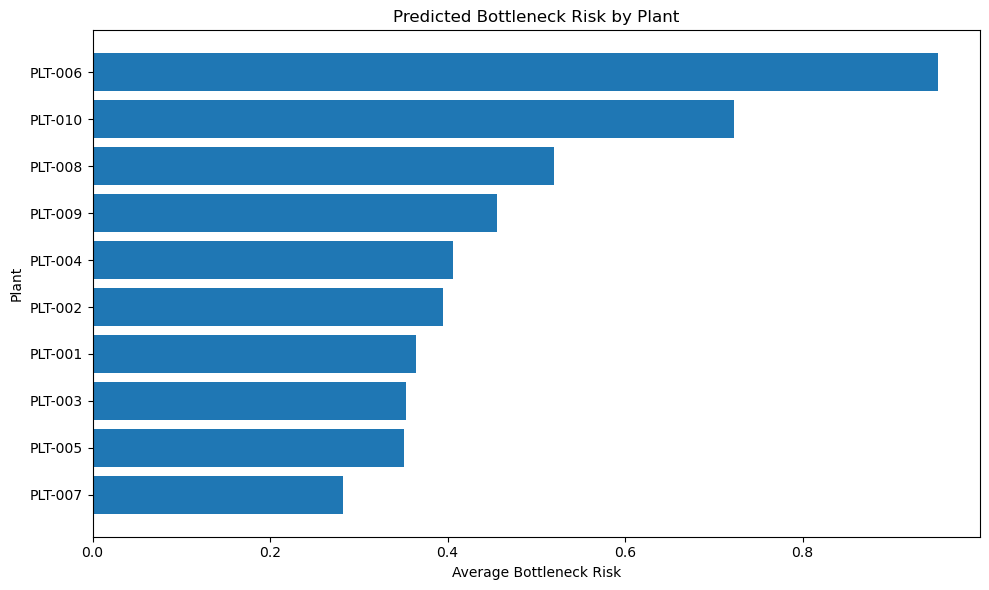

In [93]:
plot_data = final_plant_risk.sort_values(
    "Avg_Bottleneck_Risk",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["plant_id"],
    plot_data["Avg_Bottleneck_Risk"]
)

plt.xlabel("Average Bottleneck Risk")
plt.ylabel("Plant")
plt.title("Predicted Bottleneck Risk by Plant")

plt.tight_layout()
plt.show()

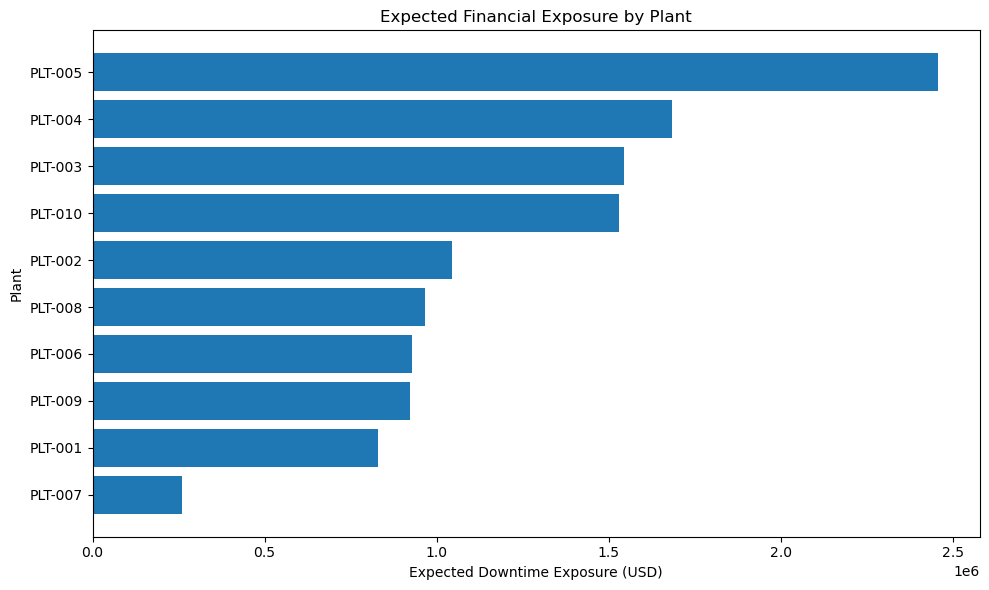

In [94]:
plot_data = final_plant_risk.sort_values(
    "Expected_Downtime_Exposure",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["plant_id"],
    plot_data["Expected_Downtime_Exposure"]
)

plt.xlabel("Expected Downtime Exposure (USD)")
plt.ylabel("Plant")
plt.title("Expected Financial Exposure by Plant")

plt.tight_layout()
plt.show()

In [95]:
def generate_recommendation(row):

    risk = row["Avg_Bottleneck_Risk"]
    oee = row["Avg_OEE"]
    exposure = row["Expected_Downtime_Exposure"]

    recommendations = []

    # Critical bottleneck
    if risk >= 0.70:
        recommendations.append(
            "Immediate bottleneck investigation"
        )
        recommendations.append(
            "Prioritize maintenance resources"
        )
        recommendations.append(
            "Review production scheduling"
        )

    # High bottleneck
    elif risk >= 0.40:
        recommendations.append(
            "Monitor bottleneck station closely"
        )
        recommendations.append(
            "Schedule preventive maintenance"
        )

    # Normal bottleneck
    else:
        recommendations.append(
            "Continue routine bottleneck monitoring"
        )

    # OEE
    if oee < 0.65:
        recommendations.append(
            "Investigate low OEE"
        )
    elif oee < 0.70:
        recommendations.append(
            "Improve OEE performance"
        )

    # Financial impact
    if exposure >= 2_000_000:
        recommendations.append(
            "High financial exposure — prioritize production continuity"
        )
    elif exposure >= 1_000_000:
        recommendations.append(
            "Review downtime reduction and production scheduling"
        )
    elif risk < 0.70:
        recommendations.append(
            "Maintain current production plan"
        )

    return " | ".join(recommendations)

In [96]:
final_plant_risk["Recommendation"] = (
    final_plant_risk.apply(
        generate_recommendation,
        axis=1
    )
)

In [97]:
print(
    final_plant_risk[
        [
            "plant_id",
            "Disruption_Level",
            "Priority_Score",
            "Recommendation"
        ]
    ].sort_values(
        "Priority_Score",
        ascending=False
    ).to_string(index=False)
)

plant_id Disruption_Level  Priority_Score                                                                                                                                                                   Recommendation
 PLT-006         Critical        0.638270                                                       Immediate bottleneck investigation | Prioritize maintenance resources | Review production scheduling | Investigate low OEE
 PLT-010         Critical        0.605104 Immediate bottleneck investigation | Prioritize maintenance resources | Review production scheduling | Investigate low OEE | Review downtime reduction and production scheduling
 PLT-005           Medium        0.546789                                                        Continue routine bottleneck monitoring | Investigate low OEE | High financial exposure — prioritize production continuity
 PLT-004             High        0.468599                                 Monitor bottleneck station closely | Schedule prev

In [98]:
final_plant_risk.to_csv(
    "final_plant_risk.csv",
    index=False
)

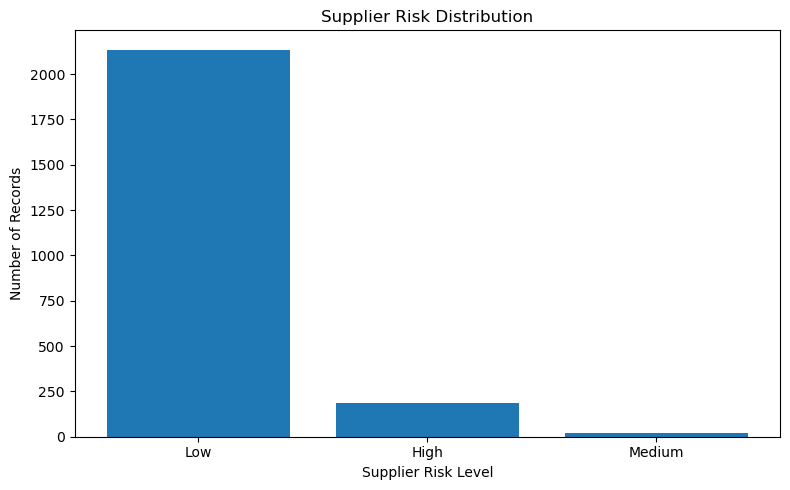

In [99]:
supplier_counts = (
    df_supplier["Supplier_Risk_Level"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    supplier_counts.index,
    supplier_counts.values
)

plt.xlabel("Supplier Risk Level")
plt.ylabel("Number of Records")
plt.title("Supplier Risk Distribution")

plt.tight_layout()
plt.show()

In [100]:
top_suppliers = (
    supplier_summary
    .sort_values(
        "Supplier_High_Risk_Probability",
        ascending=False
    )
    .head(10)
)

print(top_suppliers)

   Supplier_ID  Supplier_High_Risk_Probability  Max_Supplier_Risk  \
30        S031                        0.223685           0.999759   
1         S002                        0.178367           0.999752   
40        S041                        0.139843           0.999013   
48        S049                        0.135337           0.999685   
49        S050                        0.128496           0.999574   
26        S027                        0.120330           0.939911   
4         S005                        0.119832           0.999452   
17        S018                        0.118136           0.999535   
37        S038                        0.113947           0.999532   
23        S024                        0.112216           0.999653   

    Avg_Material_Availability  Avg_Forecasted_Demand  Avg_Reliability  \
30                 567.028571             925.057143         0.862286   
1                  634.720000             966.020000         0.857000   
40                 62

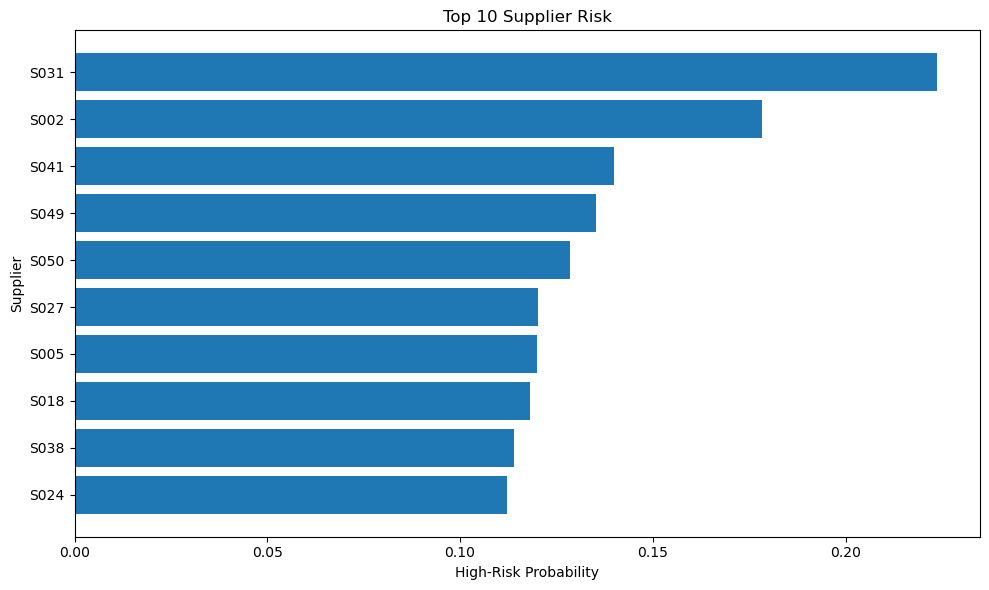

In [101]:
plt.figure(figsize=(10, 6))

plot_data = top_suppliers.sort_values(
    "Supplier_High_Risk_Probability"
)

plt.barh(
    plot_data["Supplier_ID"],
    plot_data["Supplier_High_Risk_Probability"]
)

plt.xlabel("High-Risk Probability")
plt.ylabel("Supplier")
plt.title("Top 10 Supplier Risk")

plt.tight_layout()
plt.show()

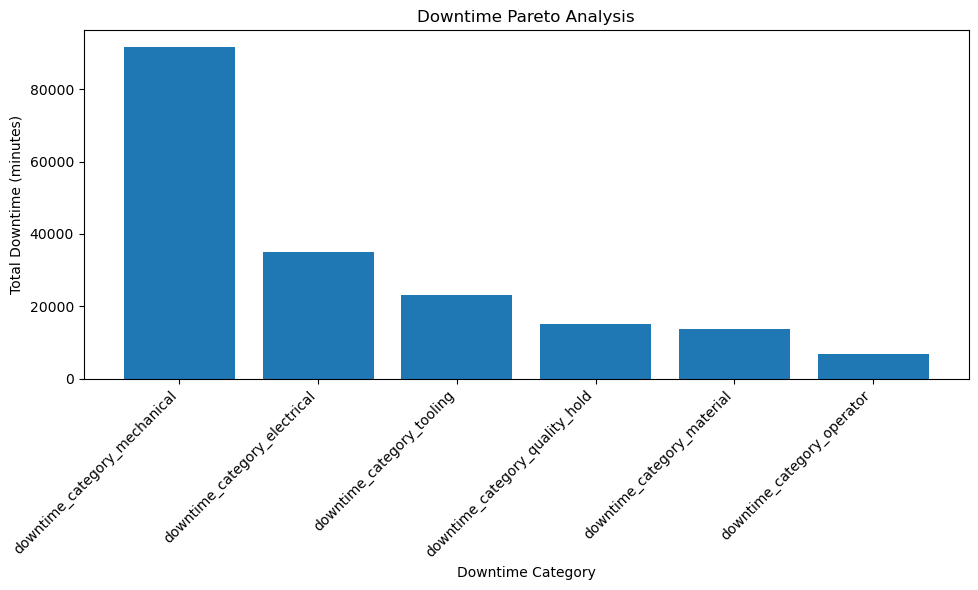

In [102]:
plt.figure(figsize=(10, 6))

plt.bar(
    df_pareto["category"],
    df_pareto["total_minutes"]
)

plt.xlabel("Downtime Category")
plt.ylabel("Total Downtime (minutes)")
plt.title("Downtime Pareto Analysis")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [103]:
print(df_oee.head())
print(df_oee.columns.tolist())

               line_id   product_family  automation_level  oee_mean   oee_std  \
0  MFG-LINE-PLT-001-01   pharmaceutical        lights_out  0.663071  0.135257   
1  MFG-LINE-PLT-001-02   pharmaceutical            manual  0.686371  0.116085   
2  MFG-LINE-PLT-002-01  electronics_pcb  highly_automated  0.609906  0.145538   
3  MFG-LINE-PLT-002-02  electronics_pcb        lights_out  0.735492  0.118093   
4  MFG-LINE-PLT-002-03  electronics_pcb  highly_automated  0.671665  0.146739   

   availability_mean  performance_mean  quality_mean  shifts  
0           0.879489          0.752761      0.998781      85  
1           0.902366          0.763371      0.997107      70  
2           0.830545          0.731336      0.997309      77  
3           0.942130          0.781253      0.999265      79  
4           0.887182          0.755074      0.997165      72  
['line_id', 'product_family', 'automation_level', 'oee_mean', 'oee_std', 'availability_mean', 'performance_mean', 'quality_mean', 'shif

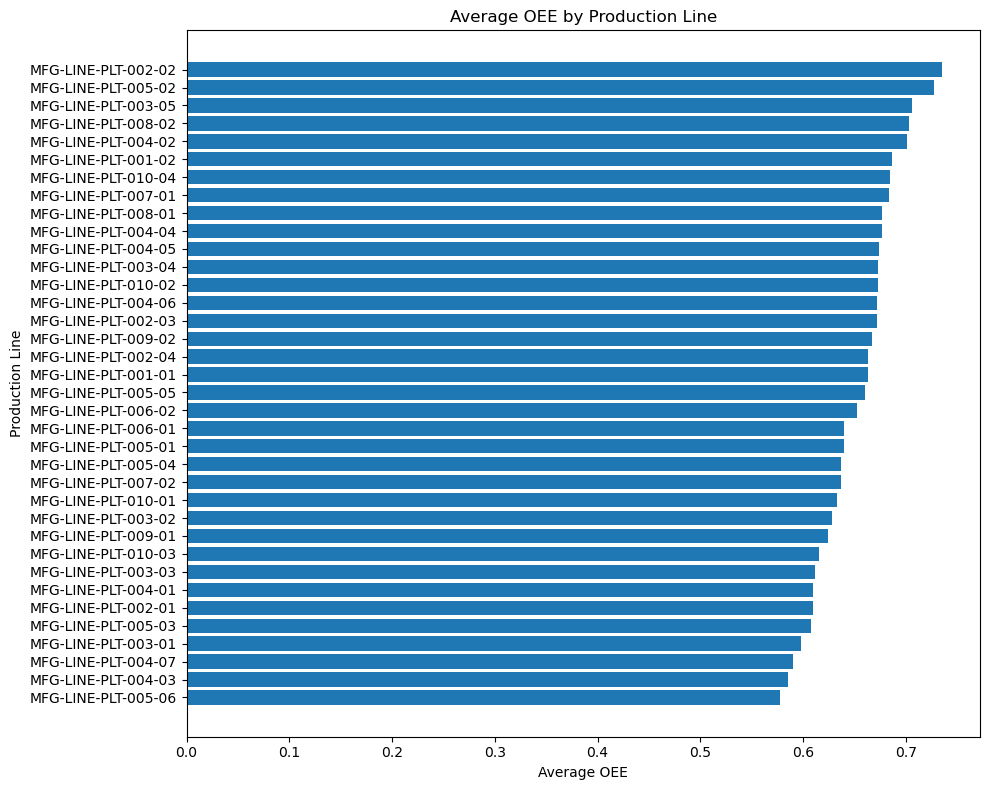

In [104]:
oee_line = (
    df_oee
    .sort_values("oee_mean", ascending=True)
)

plt.figure(figsize=(10, 8))

plt.barh(
    oee_line["line_id"],
    oee_line["oee_mean"]
)

plt.xlabel("Average OEE")
plt.ylabel("Production Line")
plt.title("Average OEE by Production Line")

plt.tight_layout()
plt.show()

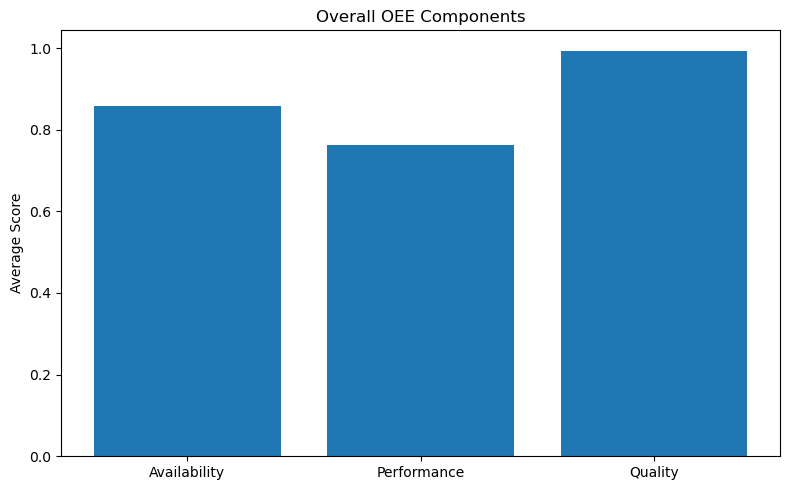

In [105]:
oee_components = df_oee[
    [
        "availability_mean",
        "performance_mean",
        "quality_mean"
    ]
].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    ["Availability", "Performance", "Quality"],
    oee_components.values
)

plt.ylabel("Average Score")
plt.title("Overall OEE Components")

plt.tight_layout()
plt.show()

In [106]:
worst_lines = (
    df_oee[
        [
            "line_id",
            "product_family",
            "automation_level",
            "oee_mean",
            "oee_std",
            "availability_mean",
            "performance_mean",
            "quality_mean",
            "shifts"
        ]
    ]
    .sort_values("oee_mean")
    .head(10)
)

print(
    worst_lines.to_string(index=False)
)

            line_id       product_family automation_level  oee_mean  oee_std  availability_mean  performance_mean  quality_mean  shifts
MFG-LINE-PLT-005-06      automotive_body highly_automated  0.577966 0.147385           0.779374          0.742094      0.994699      89
MFG-LINE-PLT-004-03 industrial_machinery highly_automated  0.585064 0.132969           0.774715          0.763573      0.990842      88
MFG-LINE-PLT-004-07 industrial_machinery highly_automated  0.590087 0.161960           0.791535          0.748572      0.986181      78
MFG-LINE-PLT-003-01      electronics_pcb highly_automated  0.597887 0.161334           0.792525          0.750134      0.998471      76
MFG-LINE-PLT-005-03      automotive_body highly_automated  0.607525 0.136447           0.795484          0.764422      0.996347      77
MFG-LINE-PLT-002-01      electronics_pcb highly_automated  0.609906 0.145538           0.830545          0.731336      0.997309      77
MFG-LINE-PLT-004-01 industrial_machinery highly_

In [107]:
plant_oee = (
    df_oee.assign(
        plant_id=df_oee["line_id"].str.extract(
            r"(PLT-\d+)"
        )[0]
    )
    .groupby("plant_id")
    .agg(
        Avg_OEE=("oee_mean", "mean"),
        Avg_Availability=("availability_mean", "mean"),
        Avg_Performance=("performance_mean", "mean"),
        Avg_Quality=("quality_mean", "mean")
    )
    .reset_index()
)

plant_oee = plant_oee.merge(
    final_plant_risk[
        [
            "plant_id",
            "Avg_Bottleneck_Risk",
            "Priority_Score",
            "Disruption_Level"
        ]
    ],
    on="plant_id",
    how="left"
)

print(
    plant_oee.sort_values(
        "Priority_Score",
        ascending=False
    ).to_string(index=False)
)

plant_id  Avg_OEE  Avg_Availability  Avg_Performance  Avg_Quality  Avg_Bottleneck_Risk  Priority_Score Disruption_Level
 PLT-006 0.646368          0.825002         0.780884     0.997286             0.952300        0.638270         Critical
 PLT-010 0.651521          0.868802         0.755785     0.986413             0.722472        0.605104         Critical
 PLT-005 0.641572          0.844971         0.758977     0.996631             0.350757        0.546789           Medium
 PLT-004 0.644176          0.848638         0.766903     0.987983             0.405911        0.468599             High
 PLT-003 0.643391          0.841135         0.763743     0.998047             0.352926        0.423468           Medium
 PLT-008 0.690173          0.899745         0.767763     0.995600             0.520503        0.418815             High
 PLT-009 0.645554          0.849686         0.761305     0.996998             0.456225        0.389406             High
 PLT-002 0.670102          0.881282     

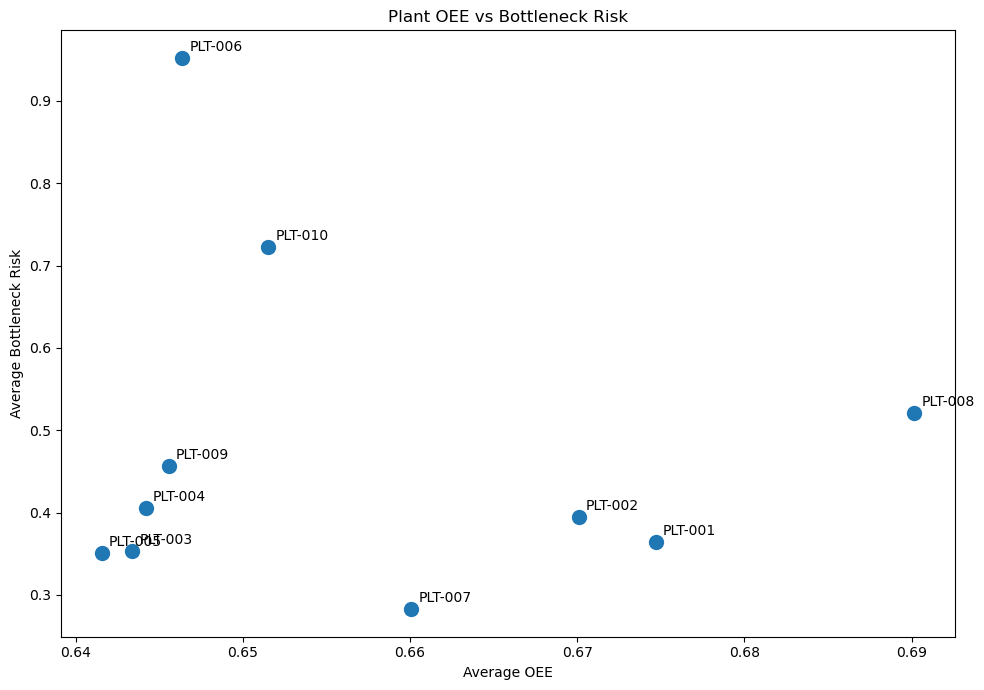

In [108]:
plot_data = plant_oee.sort_values(
    "Avg_Bottleneck_Risk",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.scatter(
    plot_data["Avg_OEE"],
    plot_data["Avg_Bottleneck_Risk"],
    s=100
)

for _, row in plot_data.iterrows():
    plt.annotate(
        row["plant_id"],
        (
            row["Avg_OEE"],
            row["Avg_Bottleneck_Risk"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Average OEE")
plt.ylabel("Average Bottleneck Risk")
plt.title("Plant OEE vs Bottleneck Risk")

plt.tight_layout()
plt.show()

In [109]:
plant_oee.to_csv(
    "plant_oee_analysis.csv",
    index=False
)

worst_lines.to_csv(
    "worst_oee_lines.csv",
    index=False
)

print("✓ plant_oee_analysis.csv")
print("✓ worst_oee_lines.csv")

✓ plant_oee_analysis.csv
✓ worst_oee_lines.csv


In [110]:
import pandas as pd
import numpy as np

# Load final outputs
final_plant_risk = pd.read_csv("final_plant_risk.csv")
supplier_predictions = pd.read_csv("supplier_predictions.csv")
bottleneck_predictions = pd.read_csv(
    "production_bottleneck_predictions.csv"
)

plant_bottleneck_summary = pd.read_csv(
    "plant_bottleneck_summary.csv"
)

# Optional OEE file if available
try:
    plant_oee_analysis = pd.read_csv("plant_oee_analysis.csv")
except FileNotFoundError:
    plant_oee_analysis = None

print("Plant risk:", final_plant_risk.shape)
print("Supplier predictions:", supplier_predictions.shape)
print("Bottleneck predictions:", bottleneck_predictions.shape)
print("Plant bottleneck summary:", plant_bottleneck_summary.shape)

Plant risk: (10, 11)
Supplier predictions: (2342, 8)
Bottleneck predictions: (3000, 9)
Plant bottleneck summary: (10, 6)


In [111]:
# Keep only the final decision-support columns
plant_backend = final_plant_risk.copy()

required_columns = [
    "plant_id",
    "Avg_Bottleneck_Risk",
    "Avg_OEE",
    "Expected_Downtime_Exposure",
    "Priority_Score",
    "Disruption_Level",
    "Recommendation"
]

missing = [
    col for col in required_columns
    if col not in plant_backend.columns
]

print("Missing columns:", missing)

if missing:
    raise ValueError(
        f"Required columns missing: {missing}"
    )

plant_backend = plant_backend[required_columns].copy()

plant_backend = plant_backend.sort_values(
    "Priority_Score",
    ascending=False
).reset_index(drop=True)

print(plant_backend)

Missing columns: []
  plant_id  Avg_Bottleneck_Risk   Avg_OEE  Expected_Downtime_Exposure  \
0  PLT-006             0.952300  0.646451                9.282185e+05   
1  PLT-010             0.722472  0.648883                1.530322e+06   
2  PLT-005             0.350757  0.642945                2.455481e+06   
3  PLT-004             0.405911  0.645064                1.684171e+06   
4  PLT-003             0.352926  0.643296                1.545116e+06   
5  PLT-008             0.520503  0.690253                9.663156e+05   
6  PLT-009             0.456225  0.647390                9.235450e+05   
7  PLT-002             0.395145  0.670003                1.045080e+06   
8  PLT-001             0.364676  0.673594                8.306169e+05   
9  PLT-007             0.282592  0.662899                2.589251e+05   

   Priority_Score Disruption_Level  \
0        0.638270         Critical   
1        0.605104         Critical   
2        0.546789           Medium   
3        0.468599       

In [112]:
backend_kpis = {
    "total_plants": int(plant_backend["plant_id"].nunique()),

    "critical_plants": int(
        (plant_backend["Disruption_Level"] == "Critical").sum()
    ),

    "high_risk_plants": int(
        (plant_backend["Disruption_Level"] == "High").sum()
    ),

    "medium_risk_plants": int(
        (plant_backend["Disruption_Level"] == "Medium").sum()
    ),

    "average_oee": float(
        plant_backend["Avg_OEE"].mean()
    ),

    "average_bottleneck_risk": float(
        plant_backend["Avg_Bottleneck_Risk"].mean()
    ),

    "total_expected_downtime_exposure": float(
        plant_backend["Expected_Downtime_Exposure"].sum()
    ),

    "highest_priority_plant": str(
        plant_backend.iloc[0]["plant_id"]
    ),

    "highest_priority_score": float(
        plant_backend.iloc[0]["Priority_Score"]
    )
}

backend_kpis

{'total_plants': 10,
 'critical_plants': 2,
 'high_risk_plants': 3,
 'medium_risk_plants': 5,
 'average_oee': 0.6570779329448274,
 'average_bottleneck_risk': 0.4803506666347265,
 'total_expected_downtime_exposure': 12167791.542292101,
 'highest_priority_plant': 'PLT-006',
 'highest_priority_score': 0.6382703102196524}

In [113]:
from pathlib import Path
import shutil

backend_dir = Path("smartfactory_backend")
backend_dir.mkdir(exist_ok=True)

# Copy final datasets
files_to_copy = [
    "final_plant_risk.csv",
    "supplier_predictions.csv",
    "production_bottleneck_predictions.csv",
    "plant_bottleneck_summary.csv",
    "plant_oee_analysis.csv",
    "worst_oee_lines.csv",
    "downtime_pareto.csv"
]

for file in files_to_copy:
    source = Path(file)

    if source.exists():
        shutil.copy2(
            source,
            backend_dir / file
        )
        print("✓", file)
    else:
        print("Skipped:", file)

✓ final_plant_risk.csv
✓ supplier_predictions.csv
✓ production_bottleneck_predictions.csv
✓ plant_bottleneck_summary.csv
✓ plant_oee_analysis.csv
✓ worst_oee_lines.csv
✓ downtime_pareto.csv


In [114]:
model_files = [
    "bottleneck_risk_model.joblib",
    "supplier_high_risk_model.joblib",
    "supplier_risk_classification_model.joblib"
]

for file in model_files:
    source = Path(file)

    if source.exists():
        shutil.copy2(
            source,
            backend_dir / file
        )
        print("✓", file)
    else:
        print("Missing:", file)

✓ bottleneck_risk_model.joblib
✓ supplier_high_risk_model.joblib
✓ supplier_risk_classification_model.joblib
